# Texas District Performance Analysis

## Introduction

This project analyzes district-level education data from Texas school districts to identify factors associated with student math achievement. Using exploratory data analysis, interactive Power BI dashboards, correlation analysis, and Linear Regression modeling, the project examines how attendance, chronic absenteeism, economic disadvantage, and other district characteristics relate to academic performance.

The primary goal of this analysis is to determine which factors are most strongly associated with math achievement and to evaluate their predictive power. Findings from this project are intended to provide data-driven insights into district performance patterns while demonstrating practical applications of data analytics and machine learning techniques in education.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## Load Datasets

In [2]:
attendance = pd.read_csv('2025 District Attendance Absenteeism Dropout.csv')

staar = pd.read_csv('2025 District STAAR All Grades.csv',low_memory=False)

student_info = pd.read_csv('2025 District Student Information.csv')

## Dataset Description

This analysis combines district-level data from three Texas Education Agency (TEA) datasets:

Attendance Dataset: District attendance rates, chronic absenteeism rates, and dropout rates.
Student Demographics Dataset: District demographic characteristics including economic disadvantage, at-risk population percentages, special education enrollment, and emergent bilingual student populations.
STAAR Performance Dataset: District-level STAAR performance outcomes for Mathematics and Reading at the Meets Grade Level standard.

The datasets were merged using the Texas six-digit district identification number to create a unified district-level analysis dataset.

## Research Questions

This project seeks to answer the following questions:

- Which district-level factors are most strongly associated with math achievement?
- How do chronic absenteeism and economic disadvantage relate to district academic performance?
- Are there districts that outperform expectations despite high levels of economic disadvantage?
- Can district math achievement be estimated using attendance and demographic indicators?

## Data Cleaning

In [3]:
# Store all datasets in a dictionary for easy inspection
datasets = {
    'Attendance': attendance,
    'Student Info': student_info,
    'STAAR': staar
}

# Review the structure of each dataset
for name, df in datasets.items():

    print(f'\n{"="*50}')
    print(f'{name} Dataset')
    print(f'{"="*50}')

    # Check the size of the dataset
    print(f'Shape: {df.shape}')

    # Preview a few column names
    print('\nFirst 10 columns:')
    print(df.columns[:10].tolist())

    # Review the data types of the first few columns
    print('\nData types:')
    print(df.dtypes.head())

    # Count missing values
    print('\nTotal missing values:')
    print(df.isna().sum().sum())


Attendance Dataset
Shape: (1209, 164)

First 10 columns:
['6 Digit County District Number', 'District Name', 'District 2024 Attendance: All Students Days Present', 'District 2024 Attendance: Two or More Races Days Present', 'District 2024 Attendance: Asian Days Present', 'District 2024 Attendance: Pacific Islander Days Present', 'District 2024 Attendance: African American Days Present', 'District 2024 Attendance: Hispanic Days Present', 'District 2024 Attendance: White Days Present', 'District 2024 Attendance: American Indian Days Present']

Data types:
6 Digit County District Number                              object
District Name                                               object
District 2024 Attendance: All Students Days Present         object
District 2024 Attendance: Two or More Races Days Present    object
District 2024 Attendance: Asian Days Present                object
dtype: object

Total missing values:
32115

Student Info Dataset
Shape: (1209, 242)

First 10 columns:
[

In [4]:
# Check whether all three datasets contain the same district IDs
attendance_ids = set(attendance['6 Digit County District Number'])
student_ids = set(student_info['6 Digit County District Number'])
staar_ids = set(staar['6 Digit County District Number'])

print(attendance_ids == student_ids == staar_ids)

True


In [5]:
# Make sure each district appears only once in each dataset
print(attendance['6 Digit County District Number'].duplicated().sum())
print(student_info['6 Digit County District Number'].duplicated().sum())
print(staar['6 Digit County District Number'].duplicated().sum())

0
0
0


In [6]:
# Combine attendance, demographic, and STAAR data into a single analysis dataset
district_data = (
    attendance
    .merge(
        student_info,
        on='6 Digit County District Number',
        how='inner'
    )
    .merge(
        staar,
        on='6 Digit County District Number',
        how='inner'
    )
)

# Verify the merge was successful
district_data.shape

(1209, 1351)

In [7]:
# Make sure each district appears only once
district_data['6 Digit County District Number'].duplicated().sum()

np.int64(0)

In [8]:
district_data.head()

,6 Digit County District Number,District Name_x,District 2024 Attendance: All Students Days Present,District 2024 Attendance: Two or More Races Days Present,District 2024 Attendance: Asian Days Present,District 2024 Attendance: Pacific Islander Days Present,District 2024 Attendance: African American Days Present,District 2024 Attendance: Hispanic Days Present,District 2024 Attendance: White Days Present,District 2024 Attendance: American Indian Days Present,...,"STAAR Performance, Science, SY 2024-25, EB/EL (Monitored & Former), % At Masters GL Standard","STAAR Performance, Science, SY 2024-25, Special Ed with Accommodations, % At Approaches GL Standard or Above","STAAR Performance, Science, SY 2024-25, Special Ed with Accommodations, % At Meets GL Standard or Above","STAAR Performance, Science, SY 2024-25, Special Ed with Accommodations, % At Masters GL Standard","STAAR Performance, Science, SY 2024-25, Special Ed without Accommodations, % At Approaches GL Standard or Above","STAAR Performance, Science, SY 2024-25, Special Ed without Accommodations, % At Meets GL Standard or Above","STAAR Performance, Science, SY 2024-25, Special Ed without Accommodations, % At Masters GL Standard","STAAR Performance, Science, SY 2024-25, Gifted and Talented, % At Approaches GL Standard or Above","STAAR Performance, Science, SY 2024-25, Gifted and Talented, % At Meets GL Standard or Above","STAAR Performance, Science, SY 2024-25, Gifted and Talented, % At Masters GL Standard"
0,DISTRICT,DISTNAME,DA0AT24N,D20AT24N,D30AT24N,D40AT24N,DB0AT24N,DH0AT24N,DW0AT24N,DI0AT24N,...,DNT00AC01325R,DNA00AC01S25R,DNA00AC01225R,DNA00AC01325R,DNW00AC01S25R,DNW00AC01225R,DNW00AC01325R,DNG00AC01S25R,DNG00AC01225R,DNG00AC01325R
1,001902,CAYUGA ISD,82927,3943,-1,NaN,3942,8517,66281,NaN,...,NaN,61,11,0,NaN,NaN,NaN,100,90,60
2,001903,ELKHART ISD,149251,5075,-1,-1,7125,19604,116281,-1,...,-1,40,15,5,75,38,38,100,93,50
3,001904,FRANKSTON ISD,105899,3936,1269,NaN,8730,13614,78046,-1,...,-1,60,10,0,89,78,22,100,100,76
4,001906,NECHES ISD,45250,1177,-1,NaN,3489,6053,34214,-1,...,NaN,50,8,0,NaN,NaN,NaN,100,100,29


In [9]:
district_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Columns: 1351 entries, 6 Digit County District Number to STAAR Performance, Science, SY 2024-25, Gifted and Talented, % At Masters GL Standard
dtypes: object(1351)
memory usage: 12.5+ MB


In [10]:
district_data.columns.tolist()

['6 Digit County District Number',
 'District Name_x',
 'District 2024 Attendance: All Students Days Present',
 'District 2024 Attendance: Two or More Races Days Present',
 'District 2024 Attendance: Asian Days Present',
 'District 2024 Attendance: Pacific Islander Days Present',
 'District 2024 Attendance: African American Days Present',
 'District 2024 Attendance: Hispanic Days Present',
 'District 2024 Attendance: White Days Present',
 'District 2024 Attendance: American Indian Days Present',
 'District 2024 Attendance: Econ Disadv Days Present',
 'District 2024 Attendance: Special Ed Days Present',
 'District 2024 Attendance: Female Days Present',
 'District 2024 Attendance: Male Days Present',
 'District 2024 Attendance: EB/EL Days Present',
 'District 2024 Attendance: At Risk Days Present',
 'District 2024 Attendance: All Students Days Membership',
 'District 2024 Attendance: Two or More Races Days Membership',
 'District 2024 Attendance: Asian Days Membership',
 'District 2024 A

In [11]:
# Look for attendance-related fields
[col for col in district_data.columns
 if 'attendance' in col.lower()]

['District 2024 Attendance: All Students Days Present',
 'District 2024 Attendance: Two or More Races Days Present',
 'District 2024 Attendance: Asian Days Present',
 'District 2024 Attendance: Pacific Islander Days Present',
 'District 2024 Attendance: African American Days Present',
 'District 2024 Attendance: Hispanic Days Present',
 'District 2024 Attendance: White Days Present',
 'District 2024 Attendance: American Indian Days Present',
 'District 2024 Attendance: Econ Disadv Days Present',
 'District 2024 Attendance: Special Ed Days Present',
 'District 2024 Attendance: Female Days Present',
 'District 2024 Attendance: Male Days Present',
 'District 2024 Attendance: EB/EL Days Present',
 'District 2024 Attendance: At Risk Days Present',
 'District 2024 Attendance: All Students Days Membership',
 'District 2024 Attendance: Two or More Races Days Membership',
 'District 2024 Attendance: Asian Days Membership',
 'District 2024 Attendance: Pacific Islander Days Membership',
 'Distric

In [12]:
# Look for absenteeism fields
[col for col in district_data.columns
 if 'absent' in col.lower()]

['2024 district Chronic Absenteeism All Students Group: Numerator',
 '2024 district Chronic Absenteeism All Students Group: Denominator',
 '2024 district Chronic Absenteeism African American Group: Numerator',
 '2024 district Chronic Absenteeism African American Group: Denominator',
 '2024 district Chronic Absenteeism Hispanic Group: Numerator',
 '2024 district Chronic Absenteeism Hispanic Group: Denominator',
 '2024 district Chronic Absenteeism White Group: Numerator',
 '2024 district Chronic Absenteeism White Group: Denominator',
 '2024 district Chronic Absenteeism American Indian Group: Numerator',
 '2024 district Chronic Absenteeism American Indian Group: Denominator',
 '2024 district Chronic Absenteeism Asian Group: Numerator',
 '2024 district Chronic Absenteeism Asian Group: Denominator',
 '2024 district Chronic Absenteeism Pacific Islander Group: Numerator',
 '2024 district Chronic Absenteeism Pacific Islander Group: Denominator',
 '2024 district Chronic Absenteeism Two or More 

In [13]:
# Look for dropout fields
[col for col in district_data.columns
 if 'dropout' in col.lower()]

['Annual Dropout Rate, Grades 07-08, SY 2023-24, All Students, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, Male, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, Female, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, Asian, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, African American, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, Hispanic, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, American Indian, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, Pacific Islander, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, Two or More Races, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, White, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, Econ Disadv, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, Special Ed, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, At Risk, Numerator',
 'Annual Dropout Rate, Grades 07-08, SY 2023-24, 

In [14]:
# Look for math fields
[col for col in district_data.columns
 if 'math' in col.lower()]

['District 2025 Class Size: Sec Math    - Avg Size',
 'STAAR Performance, Mathematics, SY 2024-25, All Students, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, African American, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, White, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Hispanic, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, American Indian, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Two or More Races, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Asian, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Pacific Islander, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Male, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Female, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Special Ed (Current), # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Non-Special Ed, # of Tests',
 'STAAR Performance, Mathematics, SY 2024-25, Econ Disadv, # of Tests',
 'STA

In [15]:
# Columns selected for the first round of analysis
columns_to_keep = [
    '6 Digit County District Number',
    'District Name_x',

    # Attendance metrics
    'District 2024 Attendance: All Students Rate',
    '2024 district Chronic Absenteeism All Students Group: Rate',

    # High school outcome metric
    'Annual Dropout Rate, Grades 09-12, SY 2023-24, All Students, Rate',

    # District demographics
    'District 2025 Student Membership: All Students Count',
    'District 2025 Student Membership: Econ Disadv Percent',
    'District 2025 Student Membership: EB/EL Percent',
    'District 2025 Student Membership: Special Ed Percent',
    'District 2025 Student Membership: At Risk Percent',

    # District racial composition
    'District 2025 Student Membership: Hispanic Percent',
    'District 2025 Student Membership: African American Percent',
    'District 2025 Student Membership: White Percent',

    # STAAR performance outcomes
    'STAAR Performance, Mathematics, SY 2024-25, All Students, % At Meets GL Standard or Above',
    'STAAR Performance, Reading/Language Arts, SY 2024-25, All Students, % At Meets GL Standard or Above'
]

# Create the final analysis dataset
district_analysis = district_data[columns_to_keep].copy()

# Rename columns to make analysis easier
district_analysis = district_analysis.rename(columns={
    '6 Digit County District Number': 'district_id',
    'District Name_x': 'district_name',
    'District 2024 Attendance: All Students Rate': 'attendance_rate',
    '2024 district Chronic Absenteeism All Students Group: Rate': 'chronic_absenteeism_rate',
    'Annual Dropout Rate, Grades 09-12, SY 2023-24, All Students, Rate': 'dropout_rate',
    'District 2025 Student Membership: All Students Count': 'student_count',
    'District 2025 Student Membership: Econ Disadv Percent': 'econ_disadv_pct',
    'District 2025 Student Membership: EB/EL Percent': 'eb_el_pct',
    'District 2025 Student Membership: Special Ed Percent': 'special_ed_pct',
    'District 2025 Student Membership: At Risk Percent': 'at_risk_pct',
    'District 2025 Student Membership: Hispanic Percent': 'hispanic_pct',
    'District 2025 Student Membership: African American Percent': 'african_american_pct',
    'District 2025 Student Membership: White Percent': 'white_pct',
    'STAAR Performance, Mathematics, SY 2024-25, All Students, % At Meets GL Standard or Above': 'math_meets_pct',
    'STAAR Performance, Reading/Language Arts, SY 2024-25, All Students, % At Meets GL Standard or Above': 'reading_meets_pct'
})

# Verify the final dataset
district_analysis.shape

(1209, 15)

In [16]:
# Review the structure of the final analysis dataset
district_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   district_id               1209 non-null   object
 1   district_name             1209 non-null   object
 2   attendance_rate           1205 non-null   object
 3   chronic_absenteeism_rate  1205 non-null   object
 4   dropout_rate              1102 non-null   object
 5   student_count             1209 non-null   object
 6   econ_disadv_pct           1209 non-null   object
 7   eb_el_pct                 1209 non-null   object
 8   special_ed_pct            1209 non-null   object
 9   at_risk_pct               1209 non-null   object
 10  hispanic_pct              1209 non-null   object
 11  african_american_pct      1209 non-null   object
 12  white_pct                 1209 non-null   object
 13  math_meets_pct            1205 non-null   object
 14  reading_meets_pct       

In [17]:
# Check the unique values in a key column
district_analysis['math_meets_pct'].unique()[:20]

array(['DDA00AM01225R', '60', '46', '55', '67', '42', '22', '54', '38',
       '50', '61', '33', '44', '14', '32', '30', '72', '73', '59', '28'],
      dtype=object)

In [18]:
# Inspect rows where math_meets_pct does not look numeric
district_analysis[
    pd.to_numeric(district_analysis['math_meets_pct'], errors='coerce').isna()
][['district_id', 'district_name', 'math_meets_pct', 'reading_meets_pct']].head(10)

,district_id,district_name,math_meets_pct,reading_meets_pct
0,DISTRICT,DISTNAME,DDA00AM01225R,DDA00AR01225R
80,015845,CELEBRATE DYSLEXIA SCHOOLS,NaN,NaN
578,108810,BRILLANTE ACADEMY,NaN,NaN
612,111801,LAKE GRANBURY ACADEMY CHARTER SCHOOL,NaN,NaN
1089,227827,THE EXCEL CENTER (FOR ADULTS),NaN,NaN


In [19]:
# Remove rows where district_id is not a real 6-digit district number
district_analysis = district_analysis[
    district_analysis['district_id'].str.match(r'^\d{6}$', na=False)
].copy()

In [20]:
# Convert analysis columns from text to numeric values
numeric_cols = [
    'attendance_rate',
    'chronic_absenteeism_rate',
    'dropout_rate',
    'student_count',
    'econ_disadv_pct',
    'eb_el_pct',
    'special_ed_pct',
    'at_risk_pct',
    'hispanic_pct',
    'african_american_pct',
    'white_pct',
    'math_meets_pct',
    'reading_meets_pct'
]

district_analysis[numeric_cols] = district_analysis[numeric_cols].apply(
    pd.to_numeric,
    errors='coerce'
)

In [21]:
# Check whether numeric conversion worked
district_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1208 entries, 1 to 1208
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   district_id               1208 non-null   object 
 1   district_name             1208 non-null   object 
 2   attendance_rate           1204 non-null   float64
 3   chronic_absenteeism_rate  1204 non-null   float64
 4   dropout_rate              1101 non-null   float64
 5   student_count             1208 non-null   int64  
 6   econ_disadv_pct           1208 non-null   float64
 7   eb_el_pct                 1208 non-null   float64
 8   special_ed_pct            1208 non-null   float64
 9   at_risk_pct               1208 non-null   float64
 10  hispanic_pct              1208 non-null   float64
 11  african_american_pct      1208 non-null   float64
 12  white_pct                 1208 non-null   float64
 13  math_meets_pct            1204 non-null   float64
 14  reading_meets

In [22]:
# Review summary statistics for the cleaned dataset
district_analysis.describe()

,attendance_rate,chronic_absenteeism_rate,dropout_rate,student_count,econ_disadv_pct,eb_el_pct,special_ed_pct,at_risk_pct,hispanic_pct,african_american_pct,white_pct,math_meets_pct,reading_meets_pct
count,1204.000000,1204.000000,1101.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1204.000000,1203.000000
mean,93.928821,16.884801,0.905904,4578.227649,59.556871,14.161838,16.199503,46.226159,44.529470,8.811589,41.253311,40.457641,52.333333
std,4.550159,10.386222,2.927160,12345.819050,21.498013,15.245784,5.553865,19.083157,26.706638,14.558477,26.956969,15.622969,14.690861
min,-1.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.900000,0.000000,0.000000,-1.000000,-1.000000
25%,93.500000,10.600000,0.000000,339.000000,46.275000,3.600000,13.300000,32.775000,22.675000,0.700000,16.800000,30.000000,43.000000
50%,94.500000,15.100000,0.200000,887.000000,61.150000,8.900000,16.000000,45.250000,39.450000,3.000000,41.100000,40.500000,52.000000
75%,95.300000,20.500000,0.900000,2912.250000,75.925000,19.100000,18.700000,57.250000,63.550000,10.800000,65.200000,50.000000,62.000000
max,100.000000,86.600000,44.500000,176039.000000,100.000000,89.700000,87.300000,100.000000,100.000000,97.500000,98.600000,87.000000,96.000000


## Exploratory Data Analysis

Before investigating relationships between district characteristics and math achievement, exploratory analysis was conducted to understand the distribution of performance outcomes across Texas school districts.

## Math Achievement Box Plot

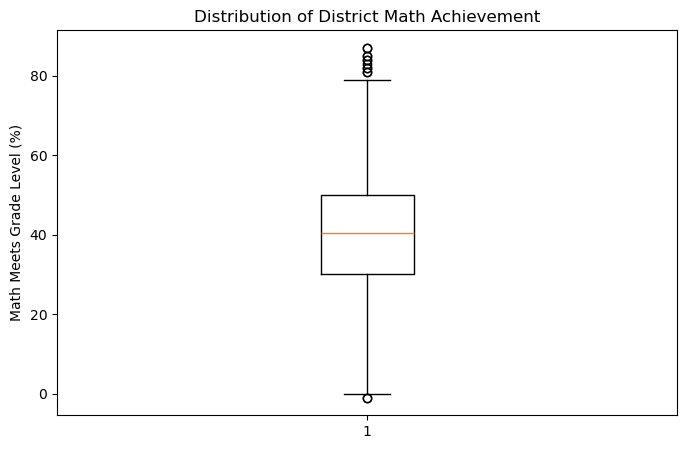

In [23]:
plt.figure(figsize=(8,5))

plt.boxplot(district_analysis['math_meets_pct'].dropna())

plt.title('Distribution of District Math Achievement')
plt.ylabel('Math Meets Grade Level (%)')

plt.show()

The distribution of district math achievement is centered around approximately 41%, with most Texas districts falling between 30% and 50% of students meeting grade-level standards. Several high-performing districts appear as outliers above 80%, while a smaller number of districts report very low achievement levels. This variation suggests that district performance differs substantially across the state, warranting further investigation into the factors associated with academic outcomes.

## District Enrollment Histogram

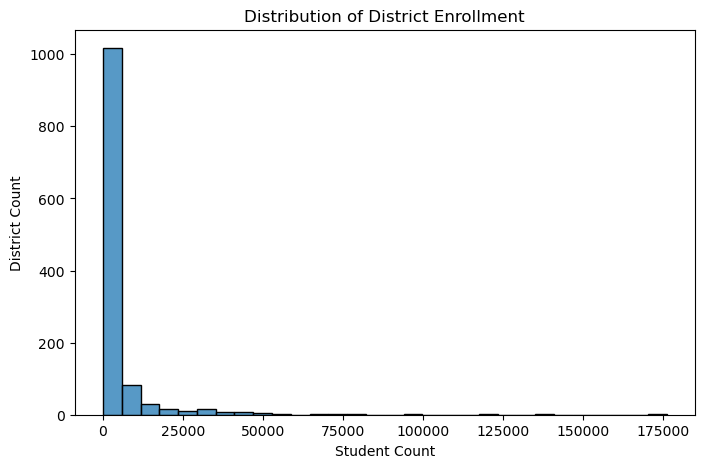

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    district_analysis['student_count'],
    bins=30
)

plt.title('Distribution of District Enrollment')
plt.xlabel('Student Count')
plt.ylabel('District Count')

plt.show()

District enrollment is highly right-skewed, indicating that most Texas school districts serve relatively small student populations while a limited number of districts enroll tens of thousands of students. The large disparity in district size highlights the diversity of educational contexts across the state and motivated the evaluation of enrollment-weighted regression models later in the analysis.


## Correlation Analysis

In [25]:
# Which factors are most correlated with Math Meets performance?
district_analysis.corr(numeric_only=True)['math_meets_pct'].sort_values()

econ_disadv_pct            -0.581867
chronic_absenteeism_rate   -0.575759
at_risk_pct                -0.474439
dropout_rate               -0.338114
hispanic_pct               -0.286702
african_american_pct       -0.281530
special_ed_pct             -0.191204
eb_el_pct                  -0.132191
student_count               0.094169
attendance_rate             0.356732
white_pct                   0.367725
reading_meets_pct           0.874462
math_meets_pct              1.000000
Name: math_meets_pct, dtype: float64

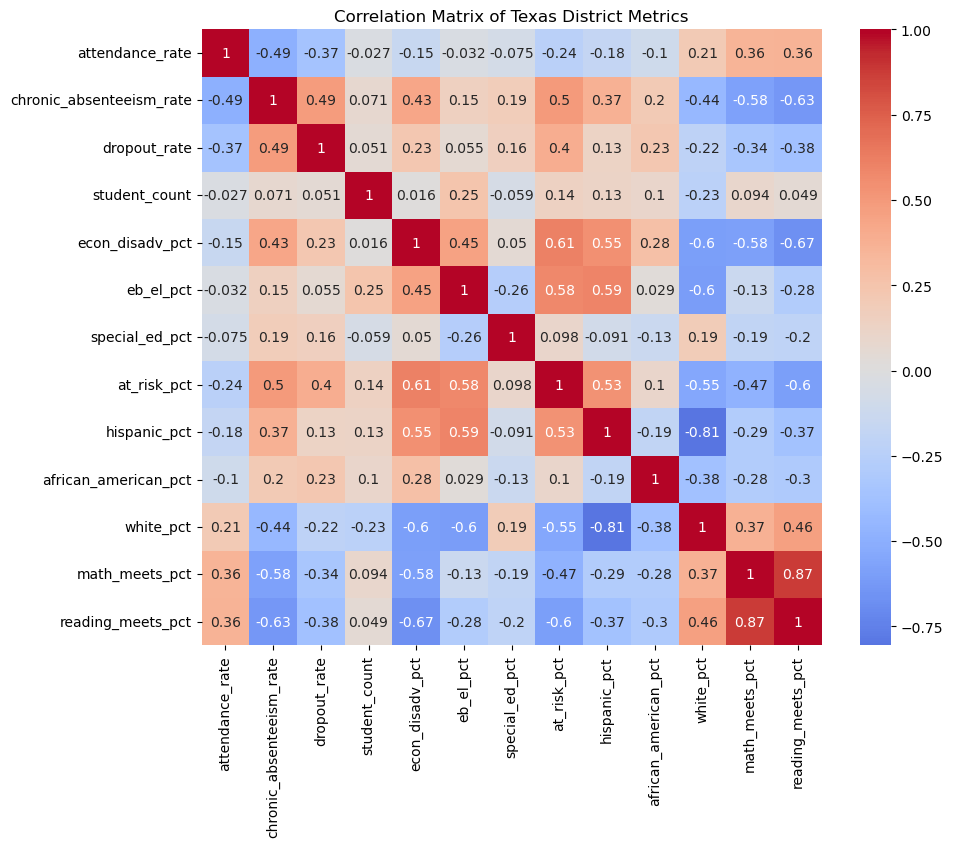

In [26]:
# Visualize relationships between key variables

plt.figure(figsize=(10, 8))

sns.heatmap(
    district_analysis.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Texas District Metrics')
plt.show()

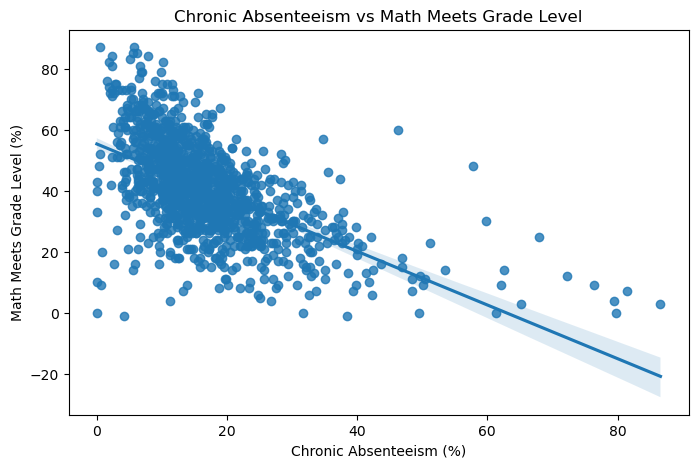

In [27]:
# Explore the relationship between chronic absenteeism and math performance

plt.figure(figsize=(8, 5))

sns.regplot(
    data=district_analysis,
    x='chronic_absenteeism_rate',
    y='math_meets_pct'
)

plt.title('Chronic Absenteeism vs Math Meets Grade Level')
plt.xlabel('Chronic Absenteeism (%)')
plt.ylabel('Math Meets Grade Level (%)')

plt.show()

Districts with higher chronic absenteeism rates tend to exhibit lower STAAR Mathematics Meets Grade Level performance. Across 1,209 Texas districts, chronic absenteeism demonstrated one of the strongest negative relationships with mathematics achievement (r = -0.576).

<Axes: xlabel='econ_disadv_pct', ylabel='math_meets_pct'>

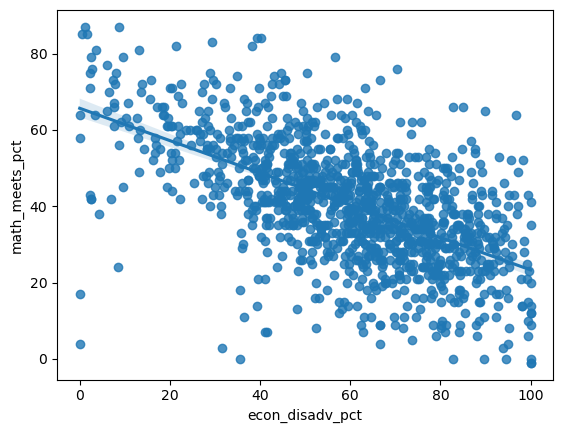

In [28]:
sns.regplot(
    data=district_analysis,
    x='econ_disadv_pct',
    y='math_meets_pct'
)

In [29]:
# High-poverty districts that outperform in math

district_analysis[
    ['district_name',
     'econ_disadv_pct',
     'math_meets_pct']
].sort_values(
    'math_meets_pct',
    ascending=False
).head(20)

,district_name,econ_disadv_pct,math_meets_pct
1051,CARROLL ISD,1.1,87.0
855,STEPHEN F AUSTIN STATE UNIVERSITY CHARTER SCHOOL,8.7,87.0
290,HIGHLAND PARK ISD,0.5,85.0
1030,WESTLAKE ACADEMY CHARTER SCHOOL,1.6,85.0
478,GRUVER ISD,39.4,84.0
707,HUNT ISD,40.3,84.0
749,DEVERS ISD,29.3,83.0
1132,NURSERY ISD,38.2,82.0
693,FALLS CITY ISD,21.4,82.0
217,LOVEJOY ISD,3.6,81.0


In [30]:
high_poverty = district_analysis[
    district_analysis['econ_disadv_pct'] >= 75
]

high_poverty.sort_values(
    'math_meets_pct',
    ascending=False
)[[
    'district_name',
    'econ_disadv_pct',
    'math_meets_pct'
]].head(15)

,district_name,econ_disadv_pct,math_meets_pct
764,RISE ACADEMY,82.7,66.0
498,HOUSTON GATEWAY ACADEMY INC,84.9,66.0
1019,ROMA ISD,89.9,65.0
496,AMIGOS POR VIDA-FRIENDS FOR LIFE PUB CHTR SCH,96.8,64.0
168,PITTSBURG ISD,75.7,62.0
1167,RAYMONDVILLE ISD,86.7,57.0
417,AMBASSADORS PREPARATORY ACADEMY,84.8,55.0
474,MEMPHIS ISD,77.5,55.0
62,HERITAGE ACADEMY,87.6,55.0
662,EHRHART SCHOOL,87.7,54.0


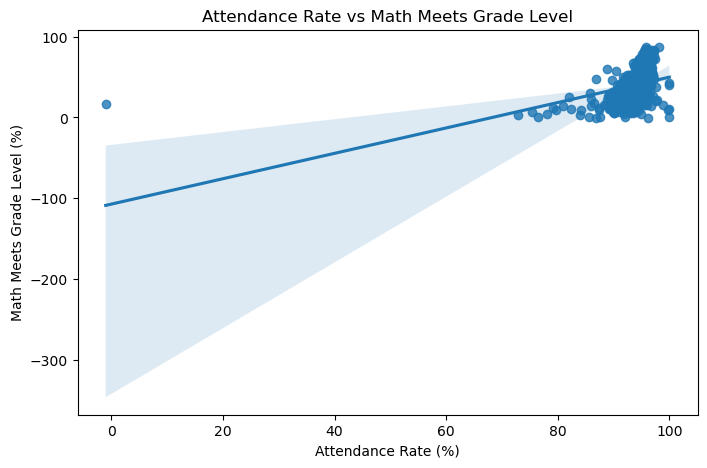

In [31]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=district_analysis,
    x='attendance_rate',
    y='math_meets_pct'
)

plt.title('Attendance Rate vs Math Meets Grade Level')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Math Meets Grade Level (%)')

plt.show()

In [32]:
math_correlations = (
    district_analysis
    .corr(numeric_only=True)['math_meets_pct']
    .sort_values()
)

math_correlations

econ_disadv_pct            -0.581867
chronic_absenteeism_rate   -0.575759
at_risk_pct                -0.474439
dropout_rate               -0.338114
hispanic_pct               -0.286702
african_american_pct       -0.281530
special_ed_pct             -0.191204
eb_el_pct                  -0.132191
student_count               0.094169
attendance_rate             0.356732
white_pct                   0.367725
reading_meets_pct           0.874462
math_meets_pct              1.000000
Name: math_meets_pct, dtype: float64

### Key Findings
- Economic disadvantage showed the strongest negative relationship with Math Meets performance (r = -0.582).
- Chronic absenteeism demonstrated a similarly strong negative relationship (r = -0.576).
- Attendance was positively associated with Math Meets performance (r = 0.357).
- Reading and Mathematics performance were strongly related (r = 0.874).

In [33]:
# Analyze factors associated with Reading performance

reading_correlations = (
    district_analysis
    .corr(numeric_only=True)['reading_meets_pct']
    .sort_values()
)

reading_correlations

econ_disadv_pct            -0.673665
chronic_absenteeism_rate   -0.633567
at_risk_pct                -0.597380
dropout_rate               -0.377013
hispanic_pct               -0.372220
african_american_pct       -0.303595
eb_el_pct                  -0.276991
special_ed_pct             -0.201743
student_count               0.049324
attendance_rate             0.362111
white_pct                   0.458252
math_meets_pct              0.874462
reading_meets_pct           1.000000
Name: reading_meets_pct, dtype: float64

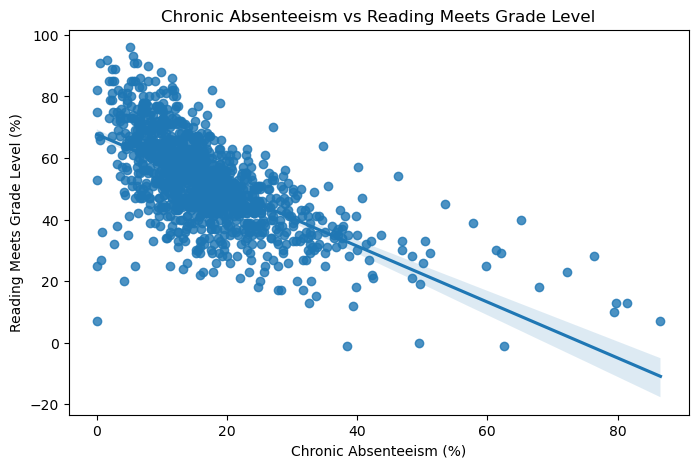

In [34]:
# Visualize the relationship between chronic absenteeism and Reading performance

plt.figure(figsize=(8,5))

sns.regplot(
    data=district_analysis,
    x='chronic_absenteeism_rate',
    y='reading_meets_pct'
)

plt.title('Chronic Absenteeism vs Reading Meets Grade Level')
plt.xlabel('Chronic Absenteeism (%)')
plt.ylabel('Reading Meets Grade Level (%)')

plt.show()

Reading performance demonstrated stronger relationships with economic disadvantage, chronic absenteeism, and at-risk populations than Mathematics performance.

In [35]:
# Identify high-poverty districts that outperform in Math

high_poverty_districts = district_analysis[
    district_analysis['econ_disadv_pct'] >= 75
]

high_poverty_math = (
    high_poverty_districts[
        ['district_name', 'econ_disadv_pct', 'math_meets_pct']
    ]
    .sort_values('math_meets_pct', ascending=False)
)

high_poverty_math.head(15)

,district_name,econ_disadv_pct,math_meets_pct
764,RISE ACADEMY,82.7,66.0
498,HOUSTON GATEWAY ACADEMY INC,84.9,66.0
1019,ROMA ISD,89.9,65.0
496,AMIGOS POR VIDA-FRIENDS FOR LIFE PUB CHTR SCH,96.8,64.0
168,PITTSBURG ISD,75.7,62.0
1167,RAYMONDVILLE ISD,86.7,57.0
417,AMBASSADORS PREPARATORY ACADEMY,84.8,55.0
474,MEMPHIS ISD,77.5,55.0
62,HERITAGE ACADEMY,87.6,55.0
662,EHRHART SCHOOL,87.7,54.0


In [36]:
# Identify high-poverty districts that outperform in Reading

high_poverty_districts = district_analysis[
    district_analysis['econ_disadv_pct'] >= 75
]

high_poverty_reading = (
    high_poverty_districts[
        ['district_name', 'econ_disadv_pct', 'reading_meets_pct']
    ]
    .sort_values('reading_meets_pct', ascending=False)
)

high_poverty_reading.head(15)

,district_name,econ_disadv_pct,reading_meets_pct
764,RISE ACADEMY,82.7,80.0
173,AVINGER ISD,75.0,68.0
498,HOUSTON GATEWAY ACADEMY INC,84.9,67.0
496,AMIGOS POR VIDA-FRIENDS FOR LIFE PUB CHTR SCH,96.8,66.0
663,BOB HOPE SCHOOL,84.2,65.0
417,AMBASSADORS PREPARATORY ACADEMY,84.8,65.0
1167,RAYMONDVILLE ISD,86.7,64.0
885,DRISCOLL ISD,95.2,64.0
662,EHRHART SCHOOL,87.7,64.0
330,HEDLEY ISD,75.3,63.0


In [37]:
# High-poverty districts with strong academic performance

high_poverty_districts = district_analysis[
    district_analysis['econ_disadv_pct'] >= 75
]

high_poverty_districts[
    [
        'district_name',
        'econ_disadv_pct',
        'math_meets_pct',
        'reading_meets_pct'
    ]
].sort_values(
    'math_meets_pct',
    ascending=False
).head(15)

,district_name,econ_disadv_pct,math_meets_pct,reading_meets_pct
764,RISE ACADEMY,82.7,66.0,80.0
498,HOUSTON GATEWAY ACADEMY INC,84.9,66.0,67.0
1019,ROMA ISD,89.9,65.0,60.0
496,AMIGOS POR VIDA-FRIENDS FOR LIFE PUB CHTR SCH,96.8,64.0,66.0
168,PITTSBURG ISD,75.7,62.0,63.0
1167,RAYMONDVILLE ISD,86.7,57.0,64.0
417,AMBASSADORS PREPARATORY ACADEMY,84.8,55.0,65.0
474,MEMPHIS ISD,77.5,55.0,58.0
62,HERITAGE ACADEMY,87.6,55.0,55.0
662,EHRHART SCHOOL,87.7,54.0,64.0


While economic disadvantage is strongly associated with lower academic performance statewide, several districts with more than 75% economically disadvantaged students achieved Math Meets rates above 50%, substantially outperforming what might be expected based on statewide trends

In [38]:
# Identify districts that outperform expectations despite high poverty levels

high_poverty_districts = district_analysis[
    district_analysis['econ_disadv_pct'] >= 75
]

high_poverty_districts[
    [
        'district_name',
        'econ_disadv_pct',
        'math_meets_pct',
        'reading_meets_pct',
        'attendance_rate',
        'chronic_absenteeism_rate'
    ]
].sort_values(
    'math_meets_pct',
    ascending=False
).head(15)

,district_name,econ_disadv_pct,math_meets_pct,reading_meets_pct,attendance_rate,chronic_absenteeism_rate
764,RISE ACADEMY,82.7,66.0,80.0,96.2,8.0
498,HOUSTON GATEWAY ACADEMY INC,84.9,66.0,67.0,96.1,6.5
1019,ROMA ISD,89.9,65.0,60.0,94.5,17.7
496,AMIGOS POR VIDA-FRIENDS FOR LIFE PUB CHTR SCH,96.8,64.0,66.0,96.6,4.9
168,PITTSBURG ISD,75.7,62.0,63.0,95.2,10.9
1167,RAYMONDVILLE ISD,86.7,57.0,64.0,90.5,34.8
417,AMBASSADORS PREPARATORY ACADEMY,84.8,55.0,65.0,95.2,10.0
474,MEMPHIS ISD,77.5,55.0,58.0,95.0,10.1
62,HERITAGE ACADEMY,87.6,55.0,55.0,95.2,10.7
662,EHRHART SCHOOL,87.7,54.0,64.0,96.1,5.5


In [39]:
correlations = district_analysis[
    ['math_meets_pct', 'chronic_absenteeism_rate', 'econ_disadv_pct']
].corr()

correlations

,math_meets_pct,chronic_absenteeism_rate,econ_disadv_pct
math_meets_pct,1.000000,-0.575759,-0.581867
chronic_absenteeism_rate,-0.575759,1.000000,0.433698
econ_disadv_pct,-0.581867,0.433698,1.000000


In [40]:
district_analysis.to_csv(
    'district_analysis_clean.csv',
    index=False
)

### Predicting Math Achievement

To move beyond correlation analysis, a Linear Regression model was developed to estimate district math achievement rates using attendance, chronic absenteeism, and economic disadvantage indicators.

In [41]:
district_analysis = district_analysis.replace(-1, np.nan)

In [42]:
district_analysis.corr(numeric_only=True)['math_meets_pct'].sort_values()

chronic_absenteeism_rate   -0.578678
econ_disadv_pct            -0.578645
at_risk_pct                -0.468219
dropout_rate               -0.333788
hispanic_pct               -0.288024
african_american_pct       -0.276848
special_ed_pct             -0.179121
eb_el_pct                  -0.134752
student_count               0.093148
white_pct                   0.366400
attendance_rate             0.513208
reading_meets_pct           0.873990
math_meets_pct              1.000000
Name: math_meets_pct, dtype: float64

In [43]:
district_analysis['student_count'].describe()

count      1208.000000
mean       4578.227649
std       12345.819050
min           9.000000
25%         339.000000
50%         887.000000
75%        2912.250000
max      176039.000000
Name: student_count, dtype: float64

## Create Modeling Dataset

In [44]:
model_data = district_analysis[
    [
        'math_meets_pct',
        'attendance_rate',
        'chronic_absenteeism_rate',
        'econ_disadv_pct'
    ]
].dropna()

print("Rows available for modeling:", len(model_data))

Rows available for modeling: 1198


## Define Features and Target

In [45]:
X = model_data[
    [
        'attendance_rate',
        'chronic_absenteeism_rate',
        'econ_disadv_pct'
    ]
]

y = model_data['math_meets_pct']

## Train-Test Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=12345
)

## Train Linear Regression Model

In [47]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Generate Predictions

In [48]:
y_pred = model.predict(X_test)

## Evaluate Model

In [49]:
print("R²:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))

R²: 0.483
MAE: 8.687


## Feature Coefficients

In [50]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,econ_disadv_pct,-0.286178
1,chronic_absenteeism_rate,-1.120906
0,attendance_rate,-2.494735


## Actual vs Predicted Plot

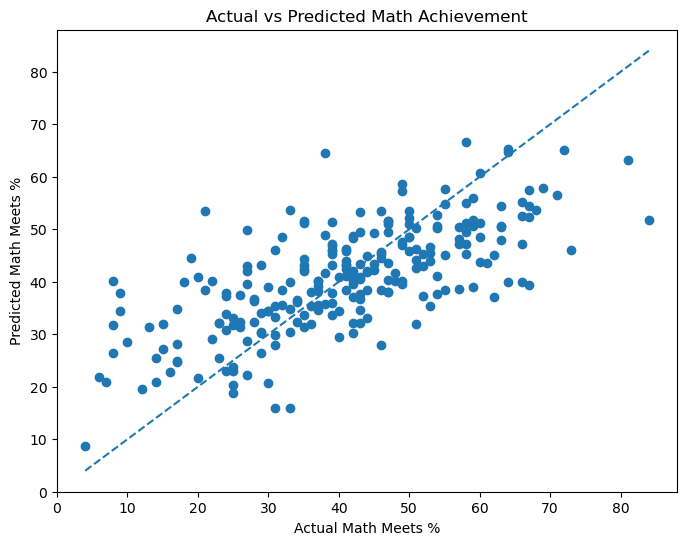

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Math Meets %")
plt.ylabel("Predicted Math Meets %")
plt.title("Actual vs Predicted Math Achievement")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.show()

The Actual vs Predicted plot demonstrates the model's ability to capture overall trends in district math achievement. While predictions generally follow the observed values, noticeable dispersion around the reference line indicates that additional factors not included in the model also contribute to district performance. This result is consistent with the model's R² value of 0.483, suggesting that attendance, chronic absenteeism, and economic disadvantage explain a meaningful, but not complete, portion of variation in math achievement.


## Model Comparison and Refinement

Several Linear Regression models were evaluated to determine which district-level factors best explained variation in math achievement outcomes.

### Model 1: Attendance, Chronic Absenteeism, and Economic Disadvantage
- Features: attendance_rate, chronic_absenteeism_rate, econ_disadv_pct
- R²: 0.483
- MAE: 8.687

This model achieved the strongest overall performance and explained approximately 48.3% of the variation in district math achievement rates.

### Model 2: Expanded Feature Set
- Features: attendance_rate, chronic_absenteeism_rate, econ_disadv_pct, at_risk_pct, dropout_rate, special_ed_pct, eb_el_pct
- R²: 0.458
- MAE: 8.572

Although additional variables were included, predictive performance did not improve meaningfully. This suggests that several of the added features may capture information already represented by attendance, absenteeism, and economic disadvantage.

### Model 3: High-Correlation Predictors Only
- Features: chronic_absenteeism_rate, econ_disadv_pct, at_risk_pct
- R²: 0.397
- MAE: 8.659

This simplified model retained the strongest negatively correlated variables but explained less variation than Model 1.

### Model 4: Enrollment-Weighted Regression
- Features: chronic_absenteeism_rate, econ_disadv_pct, at_risk_pct
- Weighted by district student enrollment
- R²: 0.049
- MAE: 10.730

Because district enrollment ranged from 9 to 176,039 students, a weighted regression model was tested to account for differences in district size. However, performance deteriorated substantially, suggesting that relationships observed across Texas districts are not driven solely by enrollment size and that larger districts may exhibit different achievement dynamics than smaller districts.

### Final Model Selection

Model 1 was selected as the final model because it achieved the highest explanatory power while remaining interpretable. Attendance rate, chronic absenteeism, and economic disadvantage were identified as the strongest district-level predictors of math achievement.

In [52]:
model_results = pd.DataFrame({
    'Model': [
        'Attendance + Absenteeism + Econ Disadvantage',
        'Expanded Feature Set',
        'Absenteeism + Econ Disadvantage + At Risk',
        'Weighted Regression'
    ],
    'R2': [0.483, 0.458, 0.397, 0.049],
    'MAE': [8.687, 8.572, 8.659, 10.730]
})

model_results

,Model,R2,MAE
0,Attendance + Absenteeism + Econ Disadvantage,0.483,8.687
1,Expanded Feature Set,0.458,8.572
2,Absenteeism + Econ Disadvantage + At Risk,0.397,8.659
3,Weighted Regression,0.049,10.730


## Limitations

Several limitations should be considered when interpreting these results:

* The analysis is conducted at the district level and does not capture variation among individual schools or students.
* Correlation does not imply causation; identified relationships should not be interpreted as direct causal effects.
* Additional factors that may influence achievement, such as teacher experience, funding levels, curriculum implementation, and community characteristics, were not included in the analysis.
* The regression models explain a meaningful portion of variation in math achievement but do not capture all factors contributing to district performance.


## Conclusion

This analysis explored district-level factors associated with math achievement across Texas school districts using both correlation analysis and predictive modeling.

Correlation analysis identified chronic absenteeism (-0.576) and economic disadvantage (-0.582) as the strongest negative relationships with math achievement. Districts with higher levels of absenteeism and economic disadvantage generally exhibited lower math performance.

Multiple Linear Regression models were evaluated to estimate district math achievement outcomes. The best-performing model, which included attendance rate, chronic absenteeism rate, and economic disadvantage percentage, explained approximately 48% of the variation in math achievement (R² = 0.483).

Together, these findings suggest that student engagement and socioeconomic conditions are among the most influential district-level factors associated with math achievement across Texas districts. While additional factors likely contribute to performance differences, attendance-related measures and economic disadvantage consistently emerged as the strongest predictors throughout the analysis.

These findings demonstrate how data visualization, statistical analysis, and predictive modeling can be used to uncover meaningful patterns in educational outcomes and support data-informed decision making at the district level